<a href="https://colab.research.google.com/github/KhaledMahaMudRajon/LinearRegressionForAI-ML/blob/main/220110(logisticRegression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Load data (adjust path after mounting Google Drive)
df = pd.read_csv('/content/drive/MyDrive/Teen_Mental_Health_Dataset.csv')
print(df.shape)
df.head()

(1200, 13)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


Check missing values:



In [2]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [3]:
df['depression_label'].value_counts(normalize=True)

,proportion
depression_label,
0,0.974167
1,0.025833


Data Preprocessing

In [4]:
X = df.drop('depression_label', axis=1)
y = df['depression_label']

Preprocessing pipeline:
We will scale numerical features and one‑hot encode categorical features.



In [17]:
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
            'academic_performance', 'physical_activity',
            'stress_level', 'anxiety_level', 'addiction_level']
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)  # drop first to avoid multicollinearity
    ])

Train‑Test‑Validation Split

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}, Test size: {X_test.shape}")

Train size: (840, 12), Validation size: (180, 12), Test size: (180, 12)


Fixing the missing value

In [8]:
# Check for missing values
print(df.isnull().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


Ensure it's integer

In [9]:
df = df.dropna(subset=['depression_label'])

df['depression_label'] = df['depression_label'].astype(int)

In [18]:
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
            'academic_performance', 'physical_activity',
            'stress_level', 'anxiety_level', 'addiction_level']
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']

# Verify all columns exist in X
missing_num = [col for col in num_cols if col not in X.columns]
missing_cat = [col for col in cat_cols if col not in X.columns]
print("Missing numerical:", missing_num)
print("Missing categorical:", missing_cat)

Missing numerical: []
Missing categorical: []


In [11]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])   # <-- close Pipeline

In [13]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])   # note the extra parenthesis

In [14]:
df = df.dropna(subset=['depression_label'])
y = df['depression_label'].astype(int)

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
            'academic_performance', 'physical_activity',
            'stress_level', 'anxiety_level', 'addiction_level']
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

 Model Training (Logistic Regression):
 It is the main function of this task


In [20]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Re-initializing model with updated preprocessor

# Train on training set
model.fit(X_train, y_train)

# Predict on validation and test sets
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

Evaluation Metrics

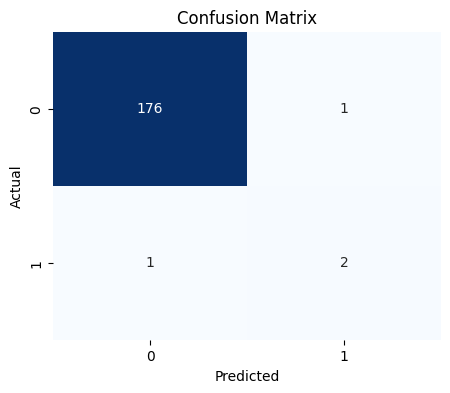

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       177
           1       0.67      0.67      0.67         3

    accuracy                           0.99       180
   macro avg       0.83      0.83      0.83       180
weighted avg       0.99      0.99      0.99       180

Accuracy: 0.9889
Precision: 0.6667
Recall: 0.6667
F1 Score: 0.6667
AUC: 0.9925


In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_test, y_test_pred))

# Accuracy, Precision, Recall, F1, AUC
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

ROC Curve


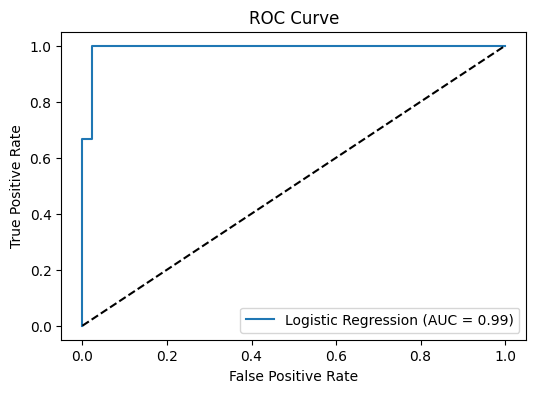

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [23]:
results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_test_pred[:10],
    'Probability': y_test_proba[:10]
})
print(results)

   Actual  Predicted   Probability
0       0          0  2.370707e-02
1       0          0  3.236659e-03
2       0          0  5.907851e-07
3       0          0  9.240377e-04
4       0          0  2.464248e-07
5       0          0  5.420971e-04
6       0          0  1.182848e-07
7       0          0  2.715591e-04
8       0          0  5.976008e-05
9       0          0  7.851661e-05


Improving Model Performance

In [24]:
# Use balanced class weights
model_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
model_balanced.fit(X_train, y_train)
# Then re‑evaluate.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age',
                                                   'daily_social_media_hours',
                                                   'sleep_hours',
                                                   'screen_time_before_sleep',
                                                   'academic_performance',
                                                   'physical_activity',
                                                   'stress_level',
                                                   'anxiety_level',
                                                   'addiction_level']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'platform_usage',
                                                   'social_interaction_level'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

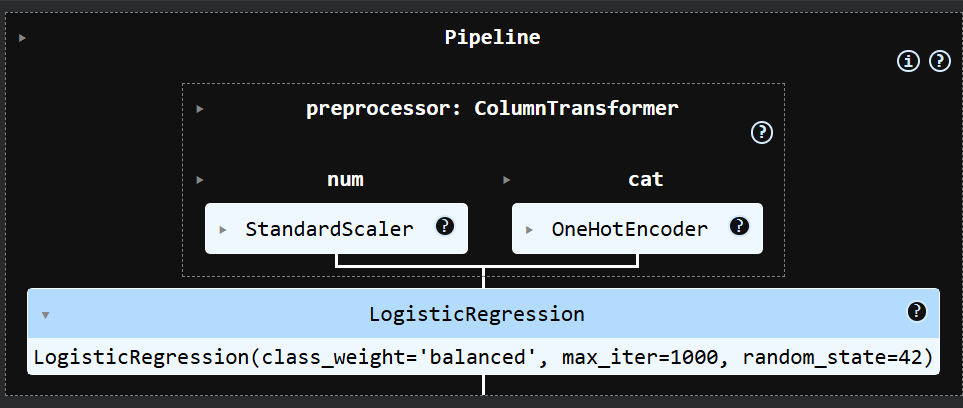